In [1]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings('ignore')

In [3]:
le = pd.read_csv('C:/Users/kseni/PycharmProjects/tpu-8e21-ai-basis/Fomina/data/raw/life_expectancy_data.csv', delimiter=',')
le.dataframeName = 'Life Expectancy Data.csv'
le.head()


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
#Переименовываем столбцы
le.rename(columns={" BMI ":"BMI","Life expectancy ":"Life_Expectancy","Adult Mortality":"Adult_Mortality",
                   "infant deaths":"Infant_Deaths","percentage expenditure":"Percentage_Exp","Hepatitis B":"HepatitisB",
                  "Measles ":"Measles"," BMI ":"BMI","under-five deaths ":"Under_Five_Deaths","Diphtheria ":"Diphtheria",
                  " HIV/AIDS":"HIV/AIDS"," thinness  1-19 years":"thinness_1to19_years"," thinness 5-9 years":"thinness_5to9_years","Income composition of resources":"Income_Comp_Of_Resources",
                   "Total expenditure":"Tot_Exp"}, inplace=True)
le.describe()


,Year,Life_Expectancy,Adult_Mortality,Infant_Deaths,Alcohol,Percentage_Exp,HepatitisB,Measles,BMI,Under_Five_Deaths,Polio,Tot_Exp,Diphtheria,HIV/AIDS,GDP,Population,thinness_1to19_years,thinness_5to9_years,Income_Comp_Of_Resources,Schooling
count,2732.000000,2724.000000,2724.000000,2732.000000,2547.000000,2732.000000,2207.000000,2732.000000,2699.000000,2732.000000,2714.000000,2517.000000,2714.000000,2732.000000,2317.000000,2.128000e+03,2699.000000,2699.000000,2577.000000,2581.000000
mean,2007.501098,69.120228,165.923642,30.588946,4.555748,727.049563,80.860897,2430.580527,38.069767,42.385066,82.409359,5.946007,82.273397,1.722328,7316.813082,1.245470e+07,4.903927,4.935495,0.624236,11.951724
std,4.626314,9.511317,123.837567,118.158278,4.034548,1974.303746,25.130776,11240.642911,20.062308,160.480411,23.421806,2.506294,23.628897,4.962085,14020.856082,5.761456e+07,4.448684,4.540056,0.211894,3.376084
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2003.000000,63.000000,75.000000,0.000000,0.850000,4.595646,77.000000,0.000000,19.100000,0.000000,77.000000,4.280000,78.000000,0.100000,464.184650,1.917392e+05,1.600000,1.600000,0.489000,10.100000
50%,2007.000000,72.000000,145.000000,3.000000,3.650000,64.395284,92.000000,17.000000,42.900000,4.000000,93.000000,5.730000,93.000000,0.100000,1741.142552,1.383743e+06,3.400000,3.400000,0.675000,12.300000
75%,2012.000000,75.600000,228.250000,23.000000,7.600000,437.086674,97.000000,370.500000,56.100000,30.000000,97.000000,7.500000,97.000000,0.800000,5828.745662,7.475598e+06,7.200000,7.300000,0.776000,14.200000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [5]:
#Смотрим тип данных и количество ненулевых значений
le.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2732 entries, 0 to 2731
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   2732 non-null   object 
 1   Year                      2732 non-null   int64  
 2   Status                    2732 non-null   object 
 3   Life_Expectancy           2724 non-null   float64
 4   Adult_Mortality           2724 non-null   float64
 5   Infant_Deaths             2732 non-null   int64  
 6   Alcohol                   2547 non-null   float64
 7   Percentage_Exp            2732 non-null   float64
 8   HepatitisB                2207 non-null   float64
 9   Measles                   2732 non-null   int64  
 10  BMI                       2699 non-null   float64
 11  Under_Five_Deaths         2732 non-null   int64  
 12  Polio                     2714 non-null   float64
 13  Tot_Exp                   2517 non-null   float64
 14  Diphther

In [6]:
#Смотрим количество нулевых значений в процентном соотношении
le.isnull().sum()*100/le.isnull().count()


Country                      0.000000
Year                         0.000000
Status                       0.000000
Life_Expectancy              0.292826
Adult_Mortality              0.292826
Infant_Deaths                0.000000
Alcohol                      6.771596
Percentage_Exp               0.000000
HepatitisB                  19.216691
Measles                      0.000000
BMI                          1.207906
Under_Five_Deaths            0.000000
Polio                        0.658858
Tot_Exp                      7.869693
Diphtheria                   0.658858
HIV/AIDS                     0.000000
GDP                         15.190337
Population                  22.108346
thinness_1to19_years         1.207906
thinness_5to9_years          1.207906
Income_Comp_Of_Resources     5.673499
Schooling                    5.527086
dtype: float64

In [7]:
#Выписываем уникальные страны (то есть убирает повторения)
country_list = le.Country.unique()
fill_list = ['Life_Expectancy','Adult_Mortality','Alcohol',
             'HepatitisB','BMI','Polio','Tot_Exp','Diphtheria','GDP',
             'Population','thinness_1to19_years','thinness_5to9_years',
             'Income_Comp_Of_Resources','Schooling']
#Интерполируем все NULL значения
for country in country_list:
    le.loc[le['Country'] == country,fill_list] = le.loc[le['Country'] == country,fill_list].interpolate()

#Выкидываем оставшиеся нулевые значения
le.dropna(inplace=True)
#Проверяем, что все выполнилось правильно
le.isnull().sum()

Country                     0
Year                        0
Status                      0
Life_Expectancy             0
Adult_Mortality             0
Infant_Deaths               0
Alcohol                     0
Percentage_Exp              0
HepatitisB                  0
Measles                     0
BMI                         0
Under_Five_Deaths           0
Polio                       0
Tot_Exp                     0
Diphtheria                  0
HIV/AIDS                    0
GDP                         0
Population                  0
thinness_1to19_years        0
thinness_5to9_years         0
Income_Comp_Of_Resources    0
Schooling                   0
dtype: int64

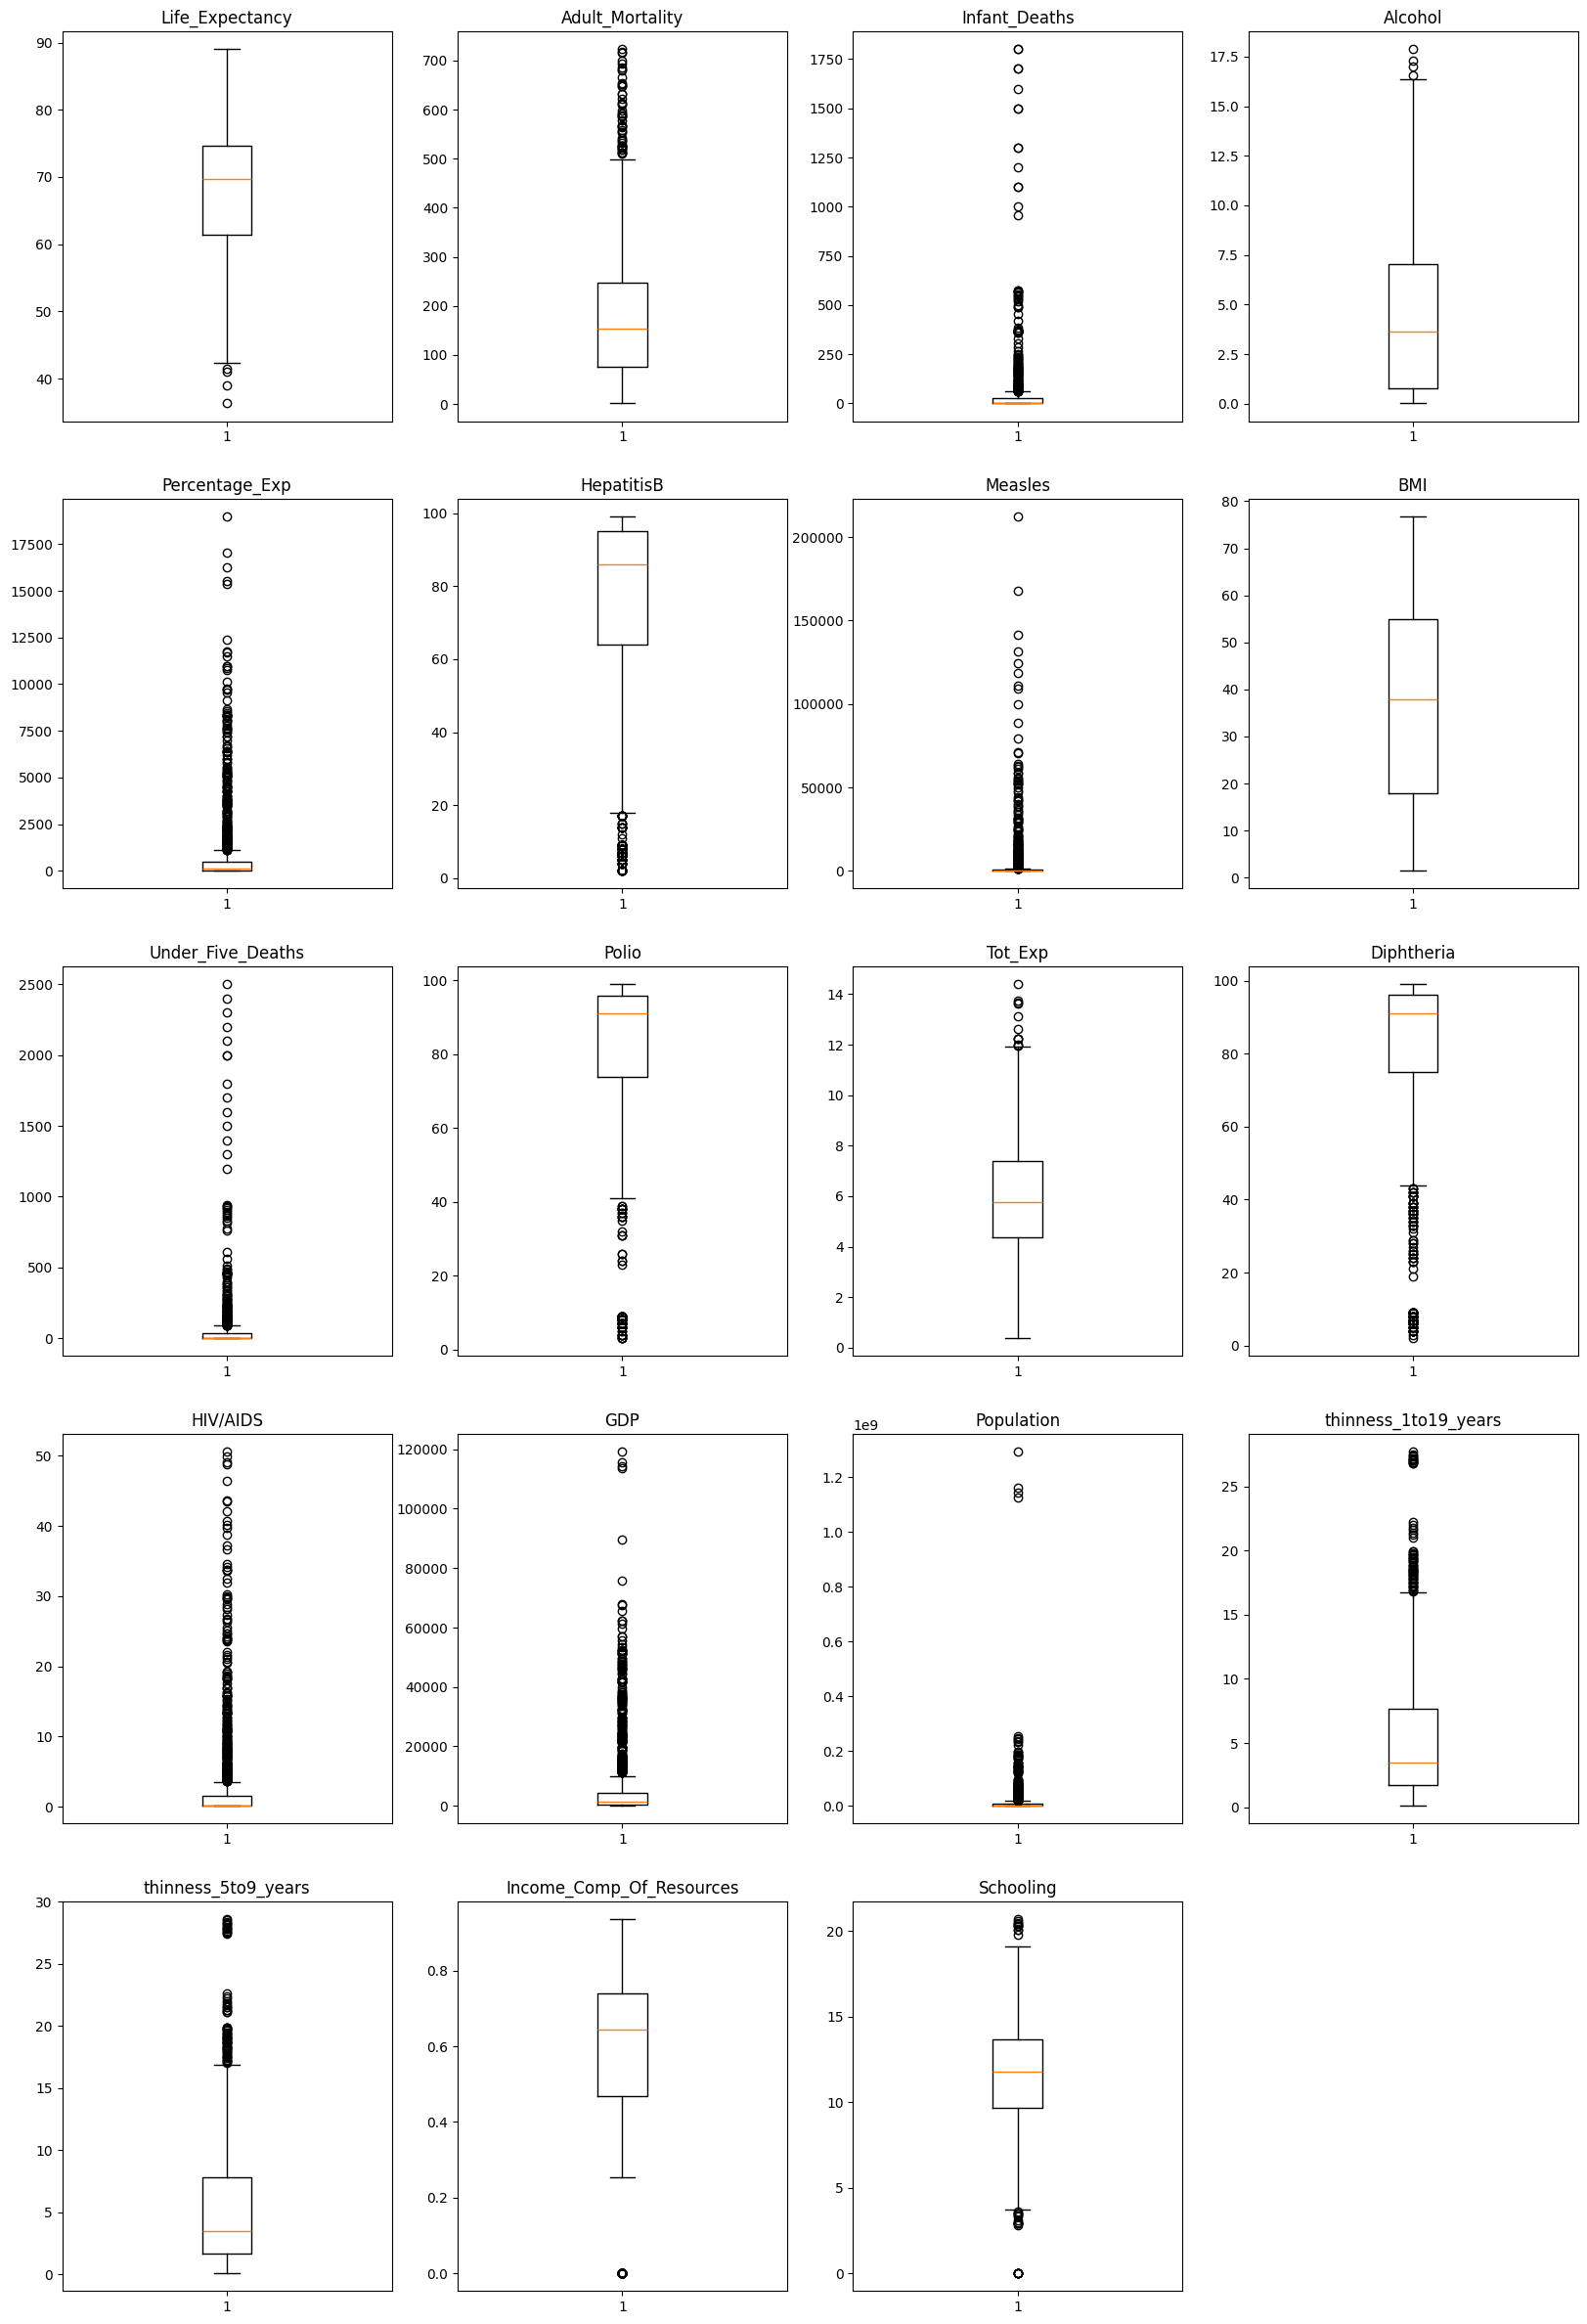

In [8]:
col_dict = {'Life_Expectancy':1,'Adult_Mortality':2,'Infant_Deaths':3,'Alcohol':4,'Percentage_Exp':5,
            'HepatitisB':6,'Measles':7,'BMI':8,'Under_Five_Deaths':9,'Polio':10,'Tot_Exp':11,
            'Diphtheria':12,'HIV/AIDS':13,'GDP':14,'Population':15,'thinness_1to19_years':16,
            'thinness_5to9_years':17,'Income_Comp_Of_Resources':18,'Schooling':19}

#Ищем "выбросные" значения в каждой категории
plt.figure(figsize=(20,30))

for variable,i in col_dict.items():
                     plt.subplot(5,4,i)
                     plt.boxplot(le[variable],whis=1.5)
                     plt.title(variable)

plt.show()

In [9]:
#Подсчитываем количество таких значений и их процентное содержание
for variable in col_dict.keys():
    q75, q25 = np.percentile(le[variable], [75 ,25])
    iqr = q75 - q25

    min_val = q25 - (iqr*1.5)
    max_val = q75 + (iqr*1.5)
    print("Number of outliers and percentage of it in {} : {} and {}".format(variable,
                                                                             len((np.where((le[variable] > max_val) |
                                                                                           (le[variable] < min_val))[0])),len((np.where((le[variable] > max_val) |
                                                                                           (le[variable] < min_val))[0]))*100/1987))

Number of outliers and percentage of it in Life_Expectancy : 4 and 0.20130850528434827
Number of outliers and percentage of it in Adult_Mortality : 49 and 2.4660291897332662
Number of outliers and percentage of it in Infant_Deaths : 192 and 9.662808253648716
Number of outliers and percentage of it in Alcohol : 4 and 0.20130850528434827
Number of outliers and percentage of it in Percentage_Exp : 214 and 10.770005032712632
Number of outliers and percentage of it in HepatitisB : 199 and 10.015098137896326
Number of outliers and percentage of it in Measles : 333 and 16.758933064921994
Number of outliers and percentage of it in BMI : 0 and 0.0
Number of outliers and percentage of it in Under_Five_Deaths : 201 and 10.1157523905385
Number of outliers and percentage of it in Polio : 142 and 7.146451937594363
Number of outliers and percentage of it in Tot_Exp : 12 and 0.6039255158530448
Number of outliers and percentage of it in Diphtheria : 171 and 8.605938600905889
Number of outliers and perc

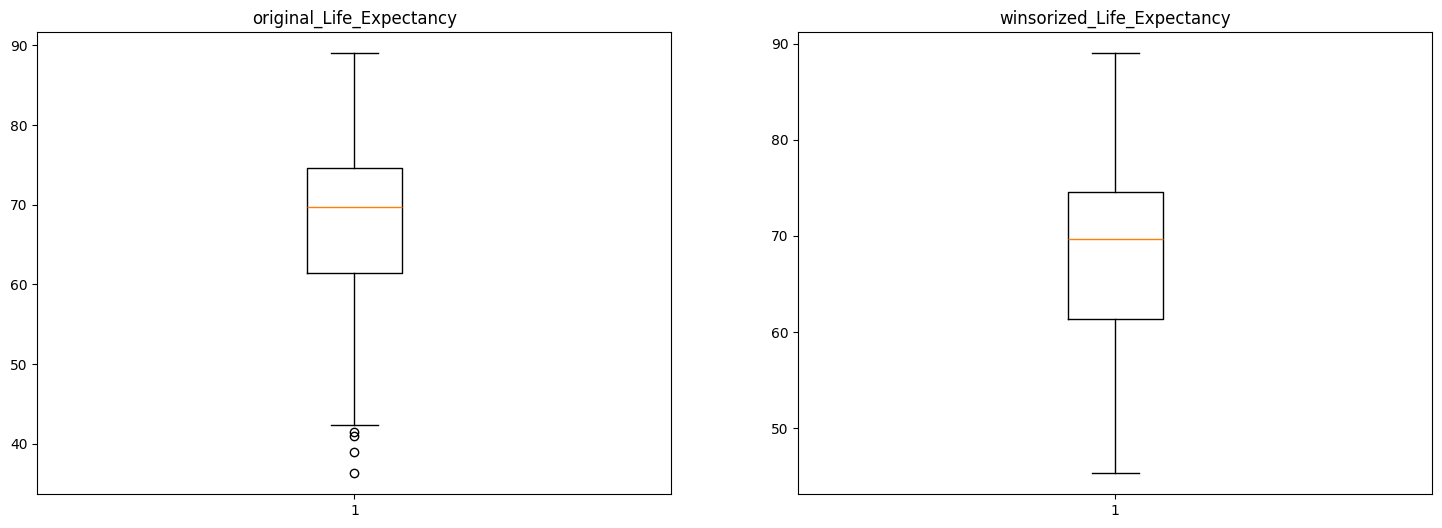

In [10]:
#Подчищаем такие значения, используя технику систематизации
from scipy.stats.mstats import winsorize
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Life_Expectancy = le['Life_Expectancy']
plt.boxplot(original_Life_Expectancy)
plt.title("original_Life_Expectancy")

plt.subplot(1,2,2)
winsorized_Life_Expectancy = winsorize(le['Life_Expectancy'], (0.01, 0))
plt.boxplot(winsorized_Life_Expectancy)
plt.title("winsorized_Life_Expectancy")

plt.show()


Text(0.5, 1.0, 'winsorized_Adult_Mortality')

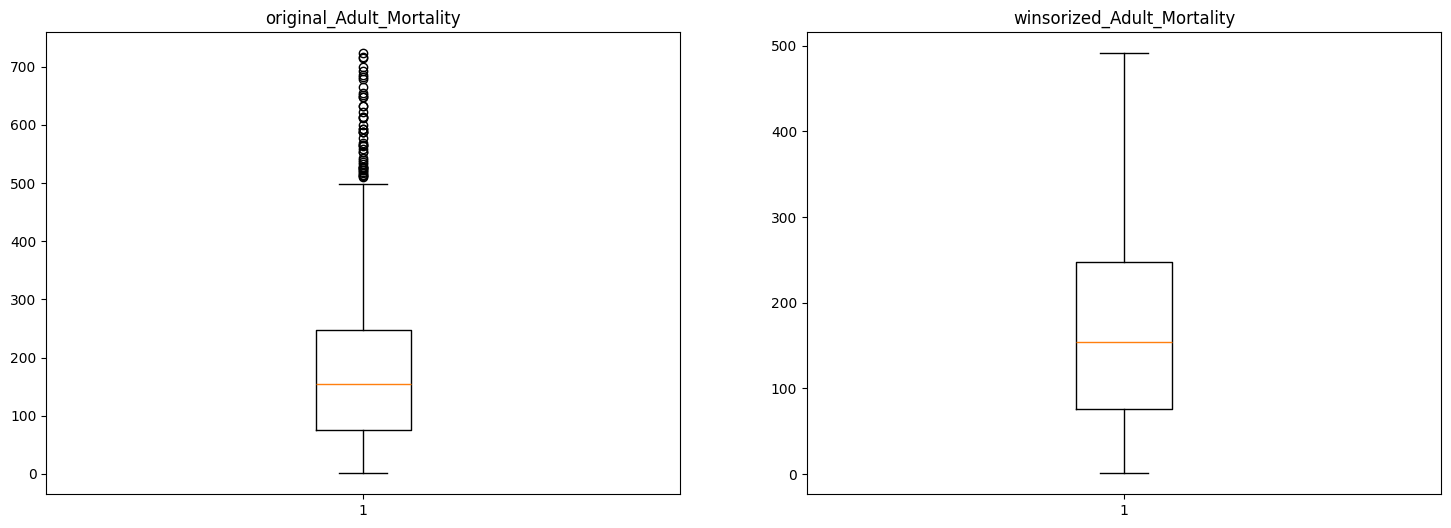

In [11]:
#Проделываем эту операцию для всех остальных свойств
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Adult_Mortality = le['Adult_Mortality']
plt.boxplot(original_Adult_Mortality)
plt.title("original_Adult_Mortality")

plt.subplot(1,2,2)
winsorized_Adult_Mortality = winsorize(le['Adult_Mortality'],(0,0.03))
plt.boxplot(winsorized_Adult_Mortality)
plt.title("winsorized_Adult_Mortality")

In [12]:
# Сохранение очищенного набора данных
le.to_csv('cleaned_life_expectancy_data.csv', index=False)
print("\nОчищенные данные сохранены в 'cleaned_life_expectancy_data.csv'")



Очищенные данные сохранены в 'cleaned_life_expectancy_data.csv'
